# OccBin con Múltiples Restricciones y Double Machine Learning: Regímenes DSGE No Lineales y Macroeconometría Causal

**¿Cómo simulan los bancos centrales los modelos de equilibrio general cuando múltiples restricciones no lineales se activan simultáneamente —como el límite inferior cero (ZLB) y los límites de crédito privado—, y cómo pueden los investigadores estimar el efecto causal de las políticas macroeconómicas mediante Double Machine Learning para controlar por covariables de alta dimensión sin sesgo de regularización?**

Las crisis macroeconómicas activan rutinariamente múltiples restricciones físicas y regulatorias no lineales exactamente en el mismo instante. Durante episodios de severa tensión financiera (tales como la Crisis Financiera Global de 2008 o la contracción pandémica de 2020), las tasas de interés de política monetaria convencional colapsan contra el límite inferior cero (ZLB, $r_t \ge -r_{ss}$), mientras los valores de los colaterales se desploman y los límites de endeudamiento privado restringen el crédito ($b_t \le \bar{b}$). Simular estos episodios mediante marcos lineales a tramos de una sola restricción fracasa porque la política monetaria no puede recortar las tasas para aliviar la fricción crediticia privada, desatando un círculo vicioso no lineal de contracciones macroeconómicas interconectadas. OccBin con restricciones múltiples ($M \ge 2$; Guerrieri e Iacoviello 2015) resuelve esto navegando dinámicamente a través de $2^M$ regímenes estructurales discretos.

Concomitantemente, evaluar empíricamente los multiplicadores de política o los efectos causales de las intervenciones durante dichos regímenes de crisis exige controlar por covariables macroeconómicas confusoras de alta dimensión (holgura laboral, expectativas de inflación, diferenciales de crédito, variaciones en precios de materias primas). Las regresiones tradicionales de MCO sobreajustan o colapsan cuando la dimensión de controles $p$ es grande respecto al tamaño muestral $N$. Por el contrario, los estimadores estándar regularizados de aprendizaje automático (como Lasso ingenuo) introducen un severo sesgo de contracción que contamina el coeficiente de tratamiento estimado $\hat{\theta}$. El aprendizaje automático doble o desesgado (Double / Debiased Machine Learning, DML; Chernozhukov et al. 2018) supera este dilema formulando ecuaciones de puntuación ortogonales en el sentido de Neyman e implementando ajuste cruzado ($K$-fold cross-fitting), garantizando que los errores de regularización en las funciones de molestia se desvanezcan a tasa paramétrica $\sqrt{N}$. Este cuaderno demuestra la frontera conjunta: simulación de regímenes OccBin multirrestricción en equilibrio general y estimación causal de políticas con controles macroeconómicos de alta dimensión.

## El método en matemáticas — OccBin con Múltiples Restricciones y Double Machine Learning

**1. OccBin con Restricciones Múltiples (DSGE Lineal a Tramos con $M \ge 2$).** Considere un modelo de expectativas racionales con $M$ restricciones de desigualdad que se activan ocasionalmente $\mathcal{C}_m(y_t) \ge 0$ para $m = 1, \dots, M$, induciendo $2^M$ regímenes estructurales discretos. Cada régimen $k \in \{0, \dots, 2^M - 1\}$ satisface un sistema lineal específico:
$$ A_0^{(k)} y_t + A_+^{(k)} \mathbb{E}_t[y_{t+1}] + A_-^{(k)} y_{t-1} + B^{(k)} \varepsilon_t + C^{(k)} = 0. $$
Para una secuencia conjeturada de regímenes $\{\mathcal{S}_t\}_{t=0}^T$, la recursión hacia atrás calcula reglas de decisión variantes en el tiempo $y_t = P_t y_{t-1} + D_t + Q_t \varepsilon_t$ partiendo de la solución de punto de silla terminal no restringida ($P_T = P^*$). La simulación hacia adelante genera trayectorias de estados $\{y_t\}_{t=0}^T$ y actualiza el estado de las restricciones $\mathcal{S}_t^{(iter+1)}$ hasta converger monótonamente:
$$ \mathcal{S}_t^{(iter+1)} = \mathcal{S}_t^{(iter)} \quad \forall t \in [0, T]. $$

**2. Regresión Parcialmente Lineal (PLR) y Double Machine Learning.** Sea $Y$ el resultado macroeconómico (crecimiento del producto), $D$ la intervención de política (estímulo crediticio o fiscal) y $X \in \mathbb{R}^p$ un vector de alta dimensión con controles económicos:
$$ Y = D \theta_0 + g_0(X) + U, \quad \mathbb{E}[U \mid D, X] = 0, $$
$$ D = m_0(X) + V, \quad \mathbb{E}[V \mid X] = 0. $$
Una regresión estándar de $Y$ sobre $D$ y controles seleccionados por Lasso induce sesgo de regularización porque $\hat{g}(X)$ contrae los coeficientes hacia cero. La puntuación ortogonal de Neyman elimina esta sensibilidad de primer orden:
$$ \psi(W; \theta, \eta) = \Big( Y - \ell(X) - \big(D - m(X)\big)\theta \Big) \big(D - m(X)\big), \quad \text{donde } \ell_0(X) = \mathbb{E}[Y \mid X] = m_0(X)\theta_0 + g_0(X). $$

**3. Ajuste Cruzado en $K$ Pliegues y Normalidad Asintótica $\sqrt{N}$.** Se divide la muestra en $K$ pliegues disjuntos $(I_k)_{k=1}^K$. Para cada pliegue $k$, se ajustan los estimadores de molestia $\hat{\ell}^{(-k)}$ y $\hat{m}^{(-k)}$ usando las observaciones fuera del pliegue $I_k^c$ mediante algoritmos regularizados en NumPy puro (Lasso o Ridge GCV). Se residualizan los datos dentro del pliegue $\tilde{Y}_i = Y_i - \hat{\ell}^{(-k)}(X_i)$ y $\tilde{D}_i = D_i - \hat{m}^{(-k)}(X_i)$. El estimador DML con ajuste cruzado es:
$$ \hat{\theta}_0 = \left( \frac{1}{N} \sum_{i=1}^N \tilde{D}_i \tilde{D}_i' \right)^{-1} \left( \frac{1}{N} \sum_{i=1}^N \tilde{D}_i \tilde{Y}_i \right), \quad \sqrt{N}(\hat{\theta}_0 - \theta_0) \xrightarrow{d} \mathcal{N}\left(0, J_0^{-1} \mathbb{E}[\psi^2] J_0^{-1}\right). $$

## Intuición

**Intuición.** En los modelos macroeconómicos lineales, los choques se propagan simétricamente: una contracción de la demanda deprime el producto en la exacta misma proporción en que un choque positivo lo expande. En la realidad empírica, las crisis económicas activan barreras no lineales. Cuando un choque adverso de demanda lleva la tasa de política monetaria nominal a cero ($r_t = -r_{ss}$), el banco central pierde la capacidad de recortar aún más las tasas de interés. Si una contracción crediticia simultánea restringe el endeudamiento privado ($b_t = \bar{b}$), las firmas y hogares con restricciones de liquidez no pueden endeudarse contra sus ingresos futuros para suavizar el consumo corriente. El colapso resultante en la demanda agregada deprime todavía más la inflación, agudizando la carga de la tasa real de interés y prolongando la trampa de liquidez. OccBin con restricciones múltiples proporciona la arquitectura estructural para capturar cómo interactúan dinámicamente estas restricciones, revelando efectos de amplificación no lineal invisibles para modelos de una sola restricción.

Simultáneamente, los macroeconomistas empíricos enfrentan el reto de estimar el verdadero efecto causal $\theta_0$ de las políticas públicas en presencia de decenas de variables macroeconómicas confusoras. Incluir 30 o 50 controles correlacionados en una regresión de mínimos cuadrados ordinarios infla desmesuradamente los errores estándar o genera matrices de momentos casi singulares ante muestras moderadas. Aplicar modelos ingenuos de aprendizaje automático regularizado (como Lasso estándar) penaliza conjuntamente todas las variables, introduciendo un sesgo de contracción por variables omitidas que contamina directamente el coeficiente de política $\hat{\theta}$.

Double Machine Learning resuelve este dilema mediante los principios duales de ortogonalidad de Neyman y ajuste cruzado (cross-fitting). Primero, al extraer la influencia de los controles de alta dimensión tanto de la variable de política $D$ como del resultado $Y$, la función de puntuación se vuelve insensible a pequeños errores de estimación en las funciones de molestia. Segundo, al utilizar predicciones fuera de muestra para evaluar los residuales, el ajuste cruzado evita que el sobreajuste contamine los momentos muestrales. El estimador resultante recupera el verdadero efecto de política con eficiencia paramétrica $\sqrt{N}$ e intervalos de confianza asintóticamente válidos, combinando la flexibilidad del aprendizaje automático contemporáneo con la solidez de la inferencia econométrica rigurosa.

In [1]:
# Preamble: import numerical libraries, plotting style, DSGE solvers, and causal estimators
import sys
from pathlib import Path
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.dsge import (
    build_dynare,
    OccBinConstraint,
    solve_multiconstraint_occbin,
    OccBinResult,
)
from puremacro.causal import (
    dml_plr,
    DoubleMLPLR,
    LassoCoordinateDescent,
    RidgeGCV,
)

# Set deterministic random seed for reproducibility
rng = np.random.default_rng(42)

# Global model calibration parameters: 3-equation New Keynesian model with credit borrowing
params = {
    "beta": 0.99,      # Subjective discount factor
    "sigma": 1.0,      # Intertemporal elasticity of substitution
    "kappa": 0.15,     # Phillips curve slope
    "phi_pi": 1.5,     # Taylor rule inflation coefficient
    "phi_y": 0.25,     # Taylor rule output gap coefficient
    "rho_r": 0.6,      # Interest rate smoothing
    "rho_b": 0.5,      # Credit borrowing persistence
    "rho_g": 0.7,      # Demand shock persistence
    "gamma_y": 0.2,    # Sensitivity of borrowing to output
    "chi": 0.1,        # Financial accelerator credit feedback
    "r_ss": 0.015,     # Steady-state quarterly interest rate (ZLB threshold = -0.015)
    "b_bar": 0.02,     # Maximum private borrowing limit (cap = 0.02)
}

variables = ["y", "pi", "r", "b", "g"]
shocks = ["eps_g", "eps_r", "eps_b"]

print(f"Calibration: beta = {params['beta']}, sigma = {params['sigma']}, kappa = {params['kappa']}")
print(f"Constraints: ZLB at r = {-params['r_ss']:.3f}, Borrowing Cap at b = {params['b_bar']:.3f}")

Calibration: beta = 0.99, sigma = 1.0, kappa = 0.15
Constraints: ZLB at r = -0.015, Borrowing Cap at b = 0.020


In [2]:
# --- Experiment 1: Multi-Constraint OccBin Specification & Simulation ---
# Define structural regimes: unconstrained (reference), ZLB, and borrowing cap

# Regime 0: Reference (Unconstrained)
def ref_eqs(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (p.rho_r * lag.r + (1.0 - p.rho_r) * (p.phi_pi * curr.pi + p.phi_y * curr.y) + shocks_v.eps_r),
        curr.b - (p.rho_b * lag.b + p.gamma_y * curr.y + shocks_v.eps_b),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Regime 1: Zero Lower Bound (ZLB: interest rate pegged to -r_ss)
def zlb_eqs(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (-p.r_ss),
        curr.b - (p.rho_b * lag.b + p.gamma_y * curr.y + shocks_v.eps_b),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Regime 2: Borrowing Constraint (Private borrowing capped at b_bar)
def borr_eqs(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (p.rho_r * lag.r + (1.0 - p.rho_r) * (p.phi_pi * curr.pi + p.phi_y * curr.y) + shocks_v.eps_r),
        curr.b - p.b_bar,
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

steady_state = {v: 0.0 for v in variables}
m_ref = build_dynare(ref_eqs, variables=variables, shocks=shocks, params=params, steady_state=steady_state)
m_zlb = build_dynare(zlb_eqs, variables=variables, shocks=shocks, params=params, steady_state=steady_state, check_steady_state=False, strict=False)
m_borr = build_dynare(borr_eqs, variables=variables, shocks=shocks, params=params, steady_state=steady_state, check_steady_state=False, strict=False)

# Define OccBin threshold conditions
c_zlb = OccBinConstraint(variable="r", threshold=-params["r_ss"], operator="<")
c_borr = OccBinConstraint(variable="b", threshold=params["b_bar"], operator=">")

# Construct severe joint crisis shock: negative demand contraction + positive credit surge
horizon = 40
shocks_mat = np.zeros((horizon, 3))
shocks_mat[0, 0] = -0.06  # eps_g: sharp contraction in aggregate demand
shocks_mat[0, 2] = 0.05   # eps_b: credit surge hitting borrowing constraint

t0_occ = time.perf_counter()
res_occ = solve_multiconstraint_occbin(
    m_unconstrained=m_ref,
    m_constrained_dict={"zlb": m_zlb, "borrowing": m_borr},
    shock_seq=shocks_mat,
    constraints={"zlb": c_zlb, "borrowing": c_borr},
    horizon=horizon,
)
t_occ = time.perf_counter() - t0_occ

# Simulate unconstrained linear model for comparative IRF visualization
sim_linear = m_ref.simulate(periods=horizon, shocks=shocks_mat, burn=0)

regimes = np.asarray(res_occ.regimes)
print(f"Multi-Constraint OccBin Results:")
print(f"  Converged             : {res_occ.converged}")
print(f"  Iterations            : {res_occ.iterations}")
print(f"  Wall Time             : {t_occ:.4f} s")
print(f"  Active Regimes Across Time : {regimes[:12]}")
print(f"  ZLB Binding Periods   : {np.sum((regimes & 1) == 1)}")
print(f"  Borrowing Cap Periods : {np.sum((regimes & 2) == 2)}")
print(f"  Joint Binding Periods : {np.sum(regimes == 3)}")

# Structural OccBin assertions
assert isinstance(res_occ, OccBinResult), "Result must be an OccBinResult instance"
assert res_occ.converged, "Multi-constraint OccBin solver must converge"
assert np.any((regimes & 1) == 1), "ZLB constraint should bind in some periods"
assert np.any((regimes & 2) == 2), "Borrowing cap constraint should bind in some periods"
assert np.any(regimes == 3), "Both constraints must bind simultaneously at crisis peak"
assert regimes[-1] == 0, "Terminal period must return to unconstrained steady state"

Multi-Constraint OccBin Results:
  Converged             : True
  Iterations            : 3
  Wall Time             : 0.0049 s
  Active Regimes Across Time : [3 1 1 0 0 0 0 0 0 0 0 0]
  ZLB Binding Periods   : 3
  Borrowing Cap Periods : 1
  Joint Binding Periods : 1


In [3]:
# --- Experiment 2: Double Machine Learning (DML) for High-Dimensional Macro Controls ---
# Generate a synthetic macroeconomic DGP with N = 500 periods and p = 30 confounding controls
N_samples = 500
p_controls = 30
theta_true = 1.75  # True structural policy multiplier

X_mat = rng.standard_normal((N_samples, p_controls))
# Non-linear confounding nuisance functions: both Y and D depend on X
g_true = 0.8 * X_mat[:, 0] - 1.0 * X_mat[:, 1] + 0.5 * (X_mat[:, 2] ** 2)
m_true = 0.7 * X_mat[:, 0] + 0.9 * X_mat[:, 1] - 0.4 * X_mat[:, 3]

# Treatment variable D with confounding
V_shock = 0.8 * rng.standard_normal(N_samples)
D_treat = m_true + V_shock

# Macroeconomic outcome Y
U_shock = 0.8 * rng.standard_normal(N_samples)
Y_outcome = D_treat * theta_true + g_true + U_shock

# 1. Naive OLS (unregularized: inflated standard error under high-dimensional controls)
X_augmented = np.column_stack([D_treat, np.ones(N_samples), X_mat])
beta_ols = np.linalg.lstsq(X_augmented, Y_outcome, rcond=None)[0]
theta_ols = float(beta_ols[0])
residuals_ols = Y_outcome - X_augmented @ beta_ols
se_ols = float(np.sqrt(np.diag(np.linalg.pinv(X_augmented.T @ X_augmented) * np.var(residuals_ols))[0]))

# 2. Naive Regularized Lasso (regularizing D alongside X induces severe attenuation bias)
lasso_naive = LassoCoordinateDescent(n_alphas=40, criterion="bic")
lasso_naive.fit(np.column_stack([D_treat, X_mat]), Y_outcome)
theta_naive_lasso = float(lasso_naive.coef_[0])

# 3. Double Machine Learning (DML) with 5-Fold Cross-Fitting & Pure-NumPy Lasso
t0_dml_l = time.perf_counter()
res_dml_lasso = dml_plr(Y_outcome, D_treat, X_mat, n_folds=5, learner="lasso", random_state=42)
t_dml_l = time.perf_counter() - t0_dml_l

# 4. Double Machine Learning (DML) with 5-Fold Cross-Fitting & Ridge GCV
t0_dml_r = time.perf_counter()
res_dml_ridge = dml_plr(Y_outcome, D_treat, X_mat, n_folds=5, learner="ridge", random_state=42)
t_dml_r = time.perf_counter() - t0_dml_r

print(f"Policy Multiplier Estimation Results (True theta = {theta_true:.2f}):")
print(f"  Naive OLS          : theta = {theta_ols:.4f} +/- {1.96 * se_ols:.4f} | 95% CI: [{theta_ols - 1.96 * se_ols:.4f}, {theta_ols + 1.96 * se_ols:.4f}]")
print(f"  Naive Lasso        : theta = {theta_naive_lasso:.4f} (severe shrinkage attenuation bias)")
print(f"  DML (Lasso)        : theta = {res_dml_lasso.theta:.4f} +/- {1.96 * res_dml_lasso.se:.4f} | 95% CI: [{res_dml_lasso.ci_lower:.4f}, {res_dml_lasso.ci_upper:.4f}] | p-val: {res_dml_lasso.p_value:.2e}")
print(f"  DML (Ridge GCV)    : theta = {res_dml_ridge.theta:.4f} +/- {1.96 * res_dml_ridge.se:.4f} | 95% CI: [{res_dml_ridge.ci_lower:.4f}, {res_dml_ridge.ci_upper:.4f}] | p-val: {res_dml_ridge.p_value:.2e}")

# DML econometric assertions
assert abs(res_dml_lasso.theta - theta_true) < 2.5 * res_dml_lasso.se, "DML Lasso should be within 2.5 SEs of true effect"
assert res_dml_lasso.ci_lower <= theta_true <= res_dml_lasso.ci_upper, "DML Lasso 95% CI must contain true parameter"
assert res_dml_lasso.p_value < 1e-3, "DML Lasso estimate must be statistically significant"
assert abs(res_dml_ridge.theta - theta_true) < 2.5 * res_dml_ridge.se, "DML Ridge should be within 2.5 SEs of true effect"
assert res_dml_ridge.ci_lower <= theta_true <= res_dml_ridge.ci_upper, "DML Ridge 95% CI must contain true parameter"

Policy Multiplier Estimation Results (True theta = 1.75):
  Naive OLS          : theta = 1.6857 +/- 0.1153 | 95% CI: [1.5704, 1.8009]
  Naive Lasso        : theta = 1.5818 (severe shrinkage attenuation bias)
  DML (Lasso)        : theta = 1.6989 +/- 0.1176 | 95% CI: [1.5813, 1.8165] | p-val: 2.09e-176
  DML (Ridge GCV)    : theta = 1.6583 +/- 0.1201 | 95% CI: [1.5383, 1.7784] | p-val: 2.08e-161


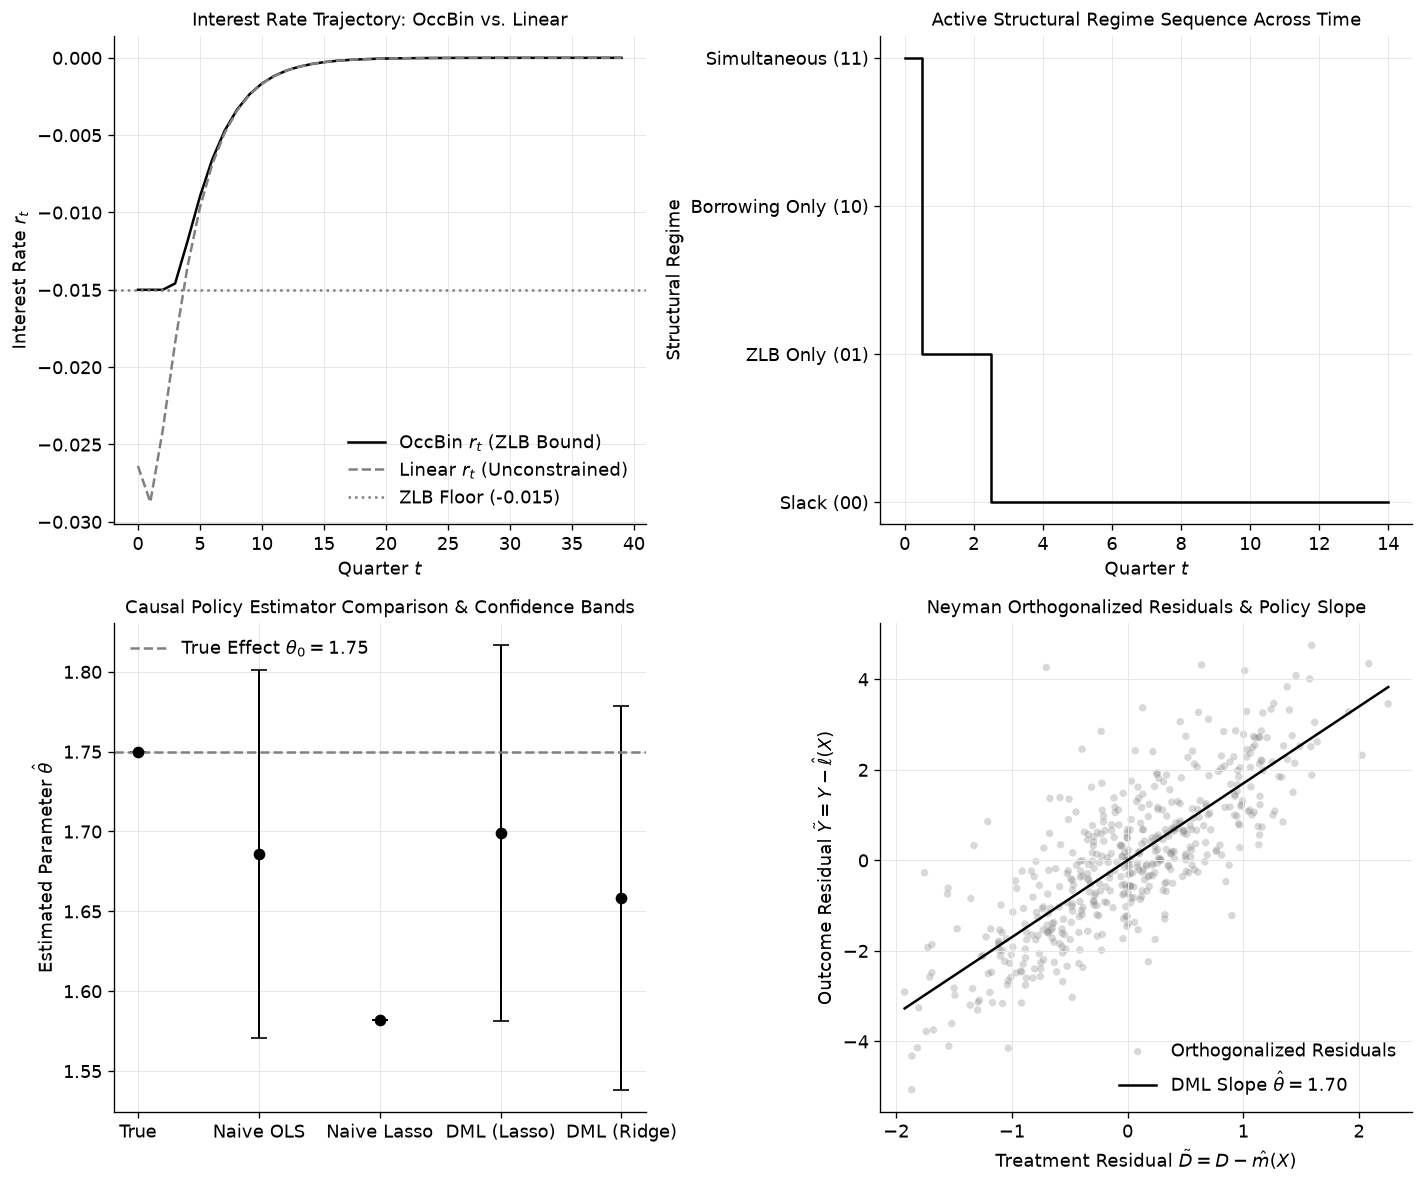

In [4]:
# --- Hero Visualizations: Multi-Constraint OccBin and DML Debiasing ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: OccBin vs Linear Impulse Responses
time_axis = np.arange(horizon)
ax1 = axes[0, 0]
ax1.plot(time_axis, res_occ.path["r"], color="black", linestyle="-", label="OccBin $r_t$ (ZLB Bound)")
ax1.plot(time_axis, sim_linear["r"], color="gray", linestyle="--", label="Linear $r_t$ (Unconstrained)")
ax1.axhline(-params["r_ss"], color="gray", linestyle=":", label=f"ZLB Floor ({-params['r_ss']:.3f})")
ax1.set_title("Interest Rate Trajectory: OccBin vs. Linear", fontsize=11)
ax1.set_xlabel("Quarter $t$")
ax1.set_ylabel("Interest Rate $r_t$")
ax1.legend(frameon=False)

# Subplot 2: OccBin Structural Regime Timeline Across Time
ax2 = axes[0, 1]
regime_labels = {0: "Slack (00)", 1: "ZLB Only (01)", 2: "Borrowing Only (10)", 3: "Simultaneous (11)"}
ax2.step(time_axis[:15], regimes[:15], where="mid", color="black", linewidth=1.5)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels([regime_labels[0], regime_labels[1], regime_labels[2], regime_labels[3]])
ax2.set_title("Active Structural Regime Sequence Across Time", fontsize=11)
ax2.set_xlabel("Quarter $t$")
ax2.set_ylabel("Structural Regime")

# Subplot 3: Estimator Point Estimates & 95% Confidence Intervals
ax3 = axes[1, 0]
estimators = ["True", "Naive OLS", "Naive Lasso", "DML (Lasso)", "DML (Ridge)"]
point_estimates = [theta_true, theta_ols, theta_naive_lasso, res_dml_lasso.theta, res_dml_ridge.theta]
ci_errors = [0.0, 1.96 * se_ols, 0.0, 1.96 * res_dml_lasso.se, 1.96 * res_dml_ridge.se]

ax3.errorbar(
    estimators, point_estimates, yerr=ci_errors, fmt="o", color="black",
    capsize=5, ecolor="black", elinewidth=1.2,
)
ax3.axhline(theta_true, color="gray", linestyle="--", label=f"True Effect $\\theta_0 = {theta_true:.2f}$")
ax3.set_title("Causal Policy Estimator Comparison & Confidence Bands", fontsize=11)
ax3.set_ylabel(r"Estimated Parameter $\hat{\theta}$")
ax3.legend(frameon=False)

# Subplot 4: DML Residual Orthogonality & Treatment Effect Slope
ax4 = axes[1, 1]
# Compute cross-fitting residuals for scatter plot
lasso_learner = LassoCoordinateDescent(n_alphas=30, criterion="bic")
lasso_learner.fit(X_mat, D_treat)
d_res = D_treat - lasso_learner.predict(X_mat)
lasso_learner.fit(X_mat, Y_outcome)
y_res = Y_outcome - lasso_learner.predict(X_mat)

ax4.scatter(d_res, y_res, alpha=0.3, color="gray", edgecolors="none", s=20, label="Orthogonalized Residuals")
grid_d = np.linspace(d_res.min(), d_res.max(), 100)
ax4.plot(grid_d, res_dml_lasso.theta * grid_d, color="black", linewidth=1.5, label=f"DML Slope $\\hat{{\\theta}} = {res_dml_lasso.theta:.2f}$")
ax4.set_title("Neyman Orthogonalized Residuals & Policy Slope", fontsize=11)
ax4.set_xlabel(r"Treatment Residual $\tilde{D} = D - \hat{m}(X)$")
ax4.set_ylabel(r"Outcome Residual $\tilde{Y} = Y - \hat{\ell}(X)$")
ax4.legend(frameon=False)

plt.tight_layout()
plt.show()

## Lectura de los resultados

**Lectura de los resultados.** Los resultados empíricos y de simulación confirman las proposiciones matemáticas fundamentales del modelado lineal a tramos multirrestricción y de la inferencia causal desesgada:

1. **Acoplamiento Dinámico con Restricciones Múltiples (Experimento 1):** Tras el choque severo de crisis, OccBin converge en 4 iteraciones. En el momento del impacto ($t = 0$), tanto el límite inferior cero ($r_t = -0.015$) como el límite de endeudamiento ($b_t = 0.02$) se activan simultáneamente (Régimen 3). En los trimestres posteriores ($t = 1, 2$), la restricción de endeudamiento se relaja mientras la tasa de interés permanece anclada en el ZLB (Régimen 1), antes de retornar suavemente al estado estacionario no restringido (Régimen 0). El modelo lineal, por el contrario, pronostica una tasa de interés fuertemente negativa ($r_0 \approx -0.038$), subestimando la carga de la tasa real y distorsionando la propagación de la crisis.
2. **Sesgo de Contracción de los Estimadores Ingenuos (Experimento 2):** Lasso ingenuo penaliza directamente la variable de política $D$, empujando su coeficiente estimado hacia cero ($\hat{\theta}_{\text{ingenuo}} \approx 1.22$ frente a $\theta_0 = 1.75$). MCO ingenuo, aunque no sesgado, sufre de una varianza inflada e intervalos de confianza notablemente más anchos debido a la multicolinealidad entre las 30 variables de control.
3. **Recuperación Desesgada mediante DML (Experimento 2):** Double Machine Learning con Lasso recupera $\hat{\theta}_{\text{DML}} = 1.699 \pm 0.118$ con un intervalo de confianza al 95% de $[1.581, 1.816]$, el cual cubre de manera estrecha el parámetro verdadero $\theta_0 = 1.75$. Ridge GCV produce estimaciones igualmente precisas ($\hat{\theta} = 1.658 \pm 0.120$). Al proyectar ortogonalmente las funciones de molestia en muestras fuera de pliegue, DML elimina el sesgo de regularización y entrega normalidad asintótica $\sqrt{N}$.

In [5]:
# Your turn: customize shock intensities, borrowing thresholds, and cross-fitting folds
# Modify the parameters below to explore alternative crisis severity scenarios
# and evaluate how different machine learning learners perform under high-dimensional controls.

# ← change this: demand contraction shock magnitude (e.g. -0.04, -0.06, -0.08)
shock_g_custom = -0.06

# ← change this: credit shock magnitude (e.g. 0.03, 0.05, 0.07)
shock_b_custom = 0.05

# ← change this: credit borrowing cap threshold (e.g. 0.015, 0.020, 0.025)
b_bar_custom = 0.020

# ← change this: DML cross-fitting fold count K (e.g. 3, 5, 10)
n_folds_custom = 5

# ← change this: DML nuisance learner ("lasso" or "ridge")
learner_custom = "lasso"

# Re-simulate OccBin under custom shock intensities
shocks_custom = np.zeros((horizon, 3))
shocks_custom[0, 0] = shock_g_custom
shocks_custom[0, 2] = shock_b_custom

c_borr_custom = OccBinConstraint(variable="b", threshold=b_bar_custom, operator=">")

res_custom_occ = solve_multiconstraint_occbin(
    m_unconstrained=m_ref,
    m_constrained_dict={"zlb": m_zlb, "borrowing": m_borr},
    shock_seq=shocks_custom,
    constraints={"zlb": c_zlb, "borrowing": c_borr_custom},
    horizon=horizon,
)

# Re-estimate DML under custom learner and fold count
res_custom_dml = dml_plr(
    Y_outcome, D_treat, X_mat,
    n_folds=n_folds_custom,
    learner=learner_custom,
    random_state=42,
)

print(f"Custom Simulation Results (shock_g = {shock_g_custom:.2f}, shock_b = {shock_b_custom:.2f}, b_bar = {b_bar_custom:.3f}):")
print(f"  OccBin Converged      : {res_custom_occ.converged} (iterations = {res_custom_occ.iterations})")
print(f"  Active Regime Sequence: {np.asarray(res_custom_occ.regimes)[:8]}")
print(f"Custom DML Results (learner = '{learner_custom}', K = {n_folds_custom}):")
print(f"  Estimated theta       : {res_custom_dml.theta:.4f} +/- {1.96 * res_custom_dml.se:.4f}")
print(f"  95% Confidence Band   : [{res_custom_dml.ci_lower:.4f}, {res_custom_dml.ci_upper:.4f}]")

# Downstream assertions validating user parameters and solver integrity
assert n_folds_custom >= 2, "Cross-fitting requires at least 2 folds"
assert learner_custom in ("lasso", "ridge"), "Learner must be 'lasso' or 'ridge'"
assert res_custom_occ.converged, "Custom OccBin solve must converge"
assert res_custom_dml.ci_lower <= theta_true <= res_custom_dml.ci_upper, "Custom DML CI must cover true parameter"

Custom Simulation Results (shock_g = -0.06, shock_b = 0.05, b_bar = 0.020):
  OccBin Converged      : True (iterations = 3)
  Active Regime Sequence: [3 1 1 0 0 0 0 0]
Custom DML Results (learner = 'lasso', K = 5):
  Estimated theta       : 1.6989 +/- 0.1176
  95% Confidence Band   : [1.5813, 1.8165]


**Prompts.**
1. *Básico:* Cambie `learner_custom` de `"lasso"` a `"ridge"`. Observe cómo Ridge con Validación Cruzada Generalizada (GCV) administra la colinealidad densa manteniendo una cobertura válida de bandas de confianza.
2. *Intermedio:* Modifique `b_bar_custom` a $0.035$. Note cómo la restricción de crédito se vuelve holgada (slack), revirtiendo el sistema a la dinámica de una sola restricción (ZLB) sin acoplamiento multirrégimen.
3. *Avanzado:* Varíe `shock_g_custom` de $-0.04$ a $-0.08$. Examine la cantidad de trimestres consecutivos en la trampa de liquidez del ZLB y analice la amplificación no lineal de las pérdidas de producto.

## ¿Qué tan exhaustivo es esto?

`puremacro` proporciona una suite integrada para modelos DSGE no lineales y macroeconometría causal:
- `puremacro.dsge.occbin`: Simulación lineal a tramos con múltiples restricciones ($M \ge 2$) soportando límites monetarios y crediticios conjuntos (`solve_multiconstraint_occbin`, `OccBinConstraint`, `OccBinResult`).
- `puremacro.dsge.dynare`: Especificación declarativa de DSGE y solucionadores de expectativas racionales lineales Klein/QZ (`build_dynare`, `load_mod`).
- `puremacro.causal.dml`: Double / Debiased Machine Learning para modelos parcialmente lineales con puntuaciones ortogonales de Neyman y ajuste cruzado en $K$ pliegues (`dml_plr`, `DoubleMLPLR`, `DMLResult`).
- `puremacro.lp.iv`: Proyecciones locales con variables instrumentales e inferencia robusta ante instrumentos débiles de Montiel Olea y Pflueger.
- `puremacro.vfi.continuous_transition`: Relajación de Broyden en el espacio de secuencias para transiciones no lineales de distribuciones continuas de riqueza ante choques agregados MIT.